# Lesson 01 — Graph Thinking and Graph Shapes

## Learning Goal

Understand what graphs are and how structure matters for algorithms and business outcomes.

By the end of this lesson, you will:
- Recognize graph patterns in real problems
- Understand that "same nodes, different structure" → different algorithms
- Know when graphs are useful and when they're not

**Duration**: 90 minutes

**Estimated time per section**:
- Concepts (directed, weighted): 15 minutes
- Five canonical shapes: 45 minutes
- Structure effects: 15 minutes
- Exercises: 15 minutes

## Setup and Helper Functions

Import libraries and define helper functions for consistent visualization and analysis.

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(G, title, figsize=(8, 6), node_size=300, layout='spring', ax=None):
    """
    Consistently visualize a graph with customizable layout.
    
    Parameters:
    - G: NetworkX graph
    - title: Graph title
    - figsize: Figure size (width, height)
    - node_size: Size of nodes
    - layout: 'spring', 'circular', 'random', or 'custom' (requires pos attribute)
    - ax: Matplotlib axis (for subplots)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Choose layout
    if layout == 'spring':
        pos = nx.spring_layout(G, seed=42, k=1, iterations=50)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'random':
        pos = nx.random_layout(G, seed=42)
    elif hasattr(G, '_pos'):
        pos = G._pos
    else:
        pos = nx.spring_layout(G, seed=42)
    
    # Draw network
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=node_size, ax=ax)
    if G.is_directed():
        nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, ax=ax, 
                               arrows=True, arrowsize=20, arrowstyle='->')
    else:
        nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Add edge weights if present
    edge_labels = nx.get_edge_attributes(G, 'weight')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    
    return pos

def print_graph_stats(G):
    """
    Print basic statistics about a graph.
    """
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    print(f"Density: {nx.density(G):.3f}")
    if G.is_directed():
        print(f"Weakly connected components: {nx.number_weakly_connected_components(G)}")
    else:
        print(f"Connected components: {nx.number_connected_components(G)}")

## 1. What is a Graph?

A **graph** is a mathematical structure that models relationships between entities.

- **Nodes** (or vertices): entities, people, documents, servers
- **Edges** (or links): relationships, connections, dependencies

Graphs are powerful when **structure matters**: approval chains, information flow, influence, risk propagation, resource allocation.

Why use graphs? Because **relationships affect outcomes**: deleting one person changes who can approve decisions; adding one connection creates redundancy; certain nodes are bottlenecks. Tabular data (rows/columns) cannot capture this structure naturally.

Nodes: 2
Edges: 1
Density: 1.000
Connected components: 1


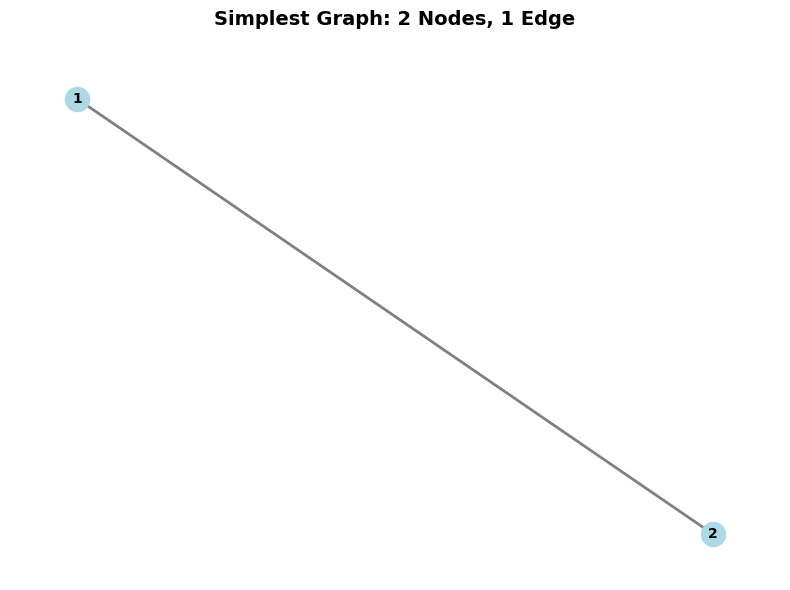

In [29]:
# Create a simple 2-node graph
G_simple = nx.Graph()
G_simple.add_nodes_from([1, 2])
G_simple.add_edge(1, 2)

visualize_graph(G_simple, "Simplest Graph: 2 Nodes, 1 Edge")
print_graph_stats(G_simple)

In [30]:
# Add attributes to nodes and edges
G_with_attrs = nx.Graph()
G_with_attrs.add_node(1, name='Alice', role='IC')
G_with_attrs.add_node(2, name='Bob', role='Manager')
G_with_attrs.add_edge(1, 2, relationship='reports_to')

# Access and display attributes
print("Nodes and their attributes:")
for node, data in G_with_attrs.nodes(data=True):
    print(f"  Node {node}: {data}")

print("\nEdges and their attributes:")
for u, v, data in G_with_attrs.edges(data=True):
    print(f"  Edge {u}-{v}: {data}")

Nodes and their attributes:
  Node 1: {'name': 'Alice', 'role': 'IC'}
  Node 2: {'name': 'Bob', 'role': 'Manager'}

Edges and their attributes:
  Edge 1-2: {'relationship': 'reports_to'}


## 2. Directed vs Undirected Graphs

**Undirected edges** represent symmetric relationships: Alice knows Bob = Bob knows Alice (friendship, collaboration).

**Directed edges** represent asymmetric relationships: Alice approves Bob's requests, but Bob cannot approve Alice's (hierarchy, approval chains, information flow).

**Impact**: Direction changes which algorithms make sense. In an undirected friendship network, path length is symmetric. In a directed approval chain, you cannot go backward.

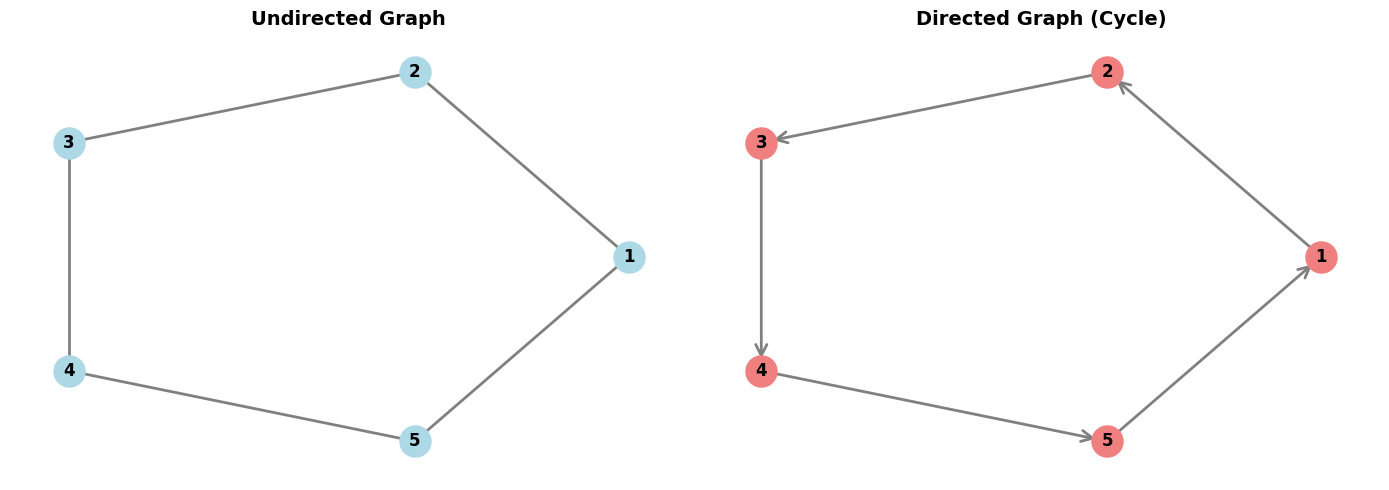

Undirected:
Nodes: 5
Edges: 5
Density: 0.500
Connected components: 1

Directed:
Nodes: 5
Edges: 5
Density: 0.250
Weakly connected components: 1


In [31]:
# Create same 5-node topology as undirected
G_undirected = nx.Graph()
G_undirected.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)])

# Create same topology as directed
G_directed = nx.DiGraph()
G_directed.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)])

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_undirected = nx.circular_layout(G_undirected)
nx.draw_networkx_nodes(G_undirected, pos_undirected, node_color='lightblue', node_size=500, ax=axes[0])
nx.draw_networkx_edges(G_undirected, pos_undirected, edge_color='gray', width=2, ax=axes[0])
nx.draw_networkx_labels(G_undirected, pos_undirected, font_size=12, font_weight='bold', ax=axes[0])
axes[0].set_title("Undirected Graph", fontsize=14, fontweight='bold')
axes[0].axis('off')

pos_directed = nx.circular_layout(G_directed)
nx.draw_networkx_nodes(G_directed, pos_directed, node_color='lightcoral', node_size=500, ax=axes[1])
nx.draw_networkx_edges(G_directed, pos_directed, edge_color='gray', width=2, ax=axes[1],
                       arrows=True, arrowsize=20, arrowstyle='->')
nx.draw_networkx_labels(G_directed, pos_directed, font_size=12, font_weight='bold', ax=axes[1])
axes[1].set_title("Directed Graph (Cycle)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Undirected:")
print_graph_stats(G_undirected)
print("\nDirected:")
print_graph_stats(G_directed)

## 3. Weighted Graphs

**Weights** on edges represent costs, confidence, time, frequency, or importance.

Examples:
- **Approval chain**: weight = approval time (days)
- **Communication network**: weight = message frequency
- **Supply chain**: weight = shipping cost
- **Trust network**: weight = confidence level (0-1)

**Impact**: Weighted graphs reveal which paths are expensive, fast, or risky. Algorithms like shortest path become "cheapest path" or "fastest path."

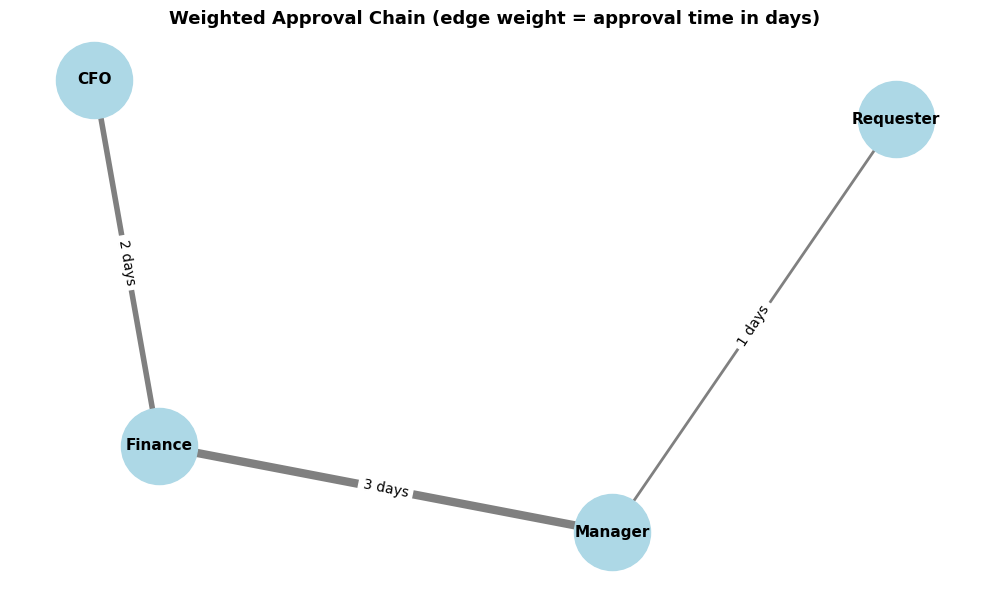

Nodes: 4
Edges: 3
Density: 0.250
Weakly connected components: 1


In [32]:
# Create a weighted approval chain
G_weighted = nx.DiGraph()
G_weighted.add_edges_from([
    ('Requester', 'Manager', {'weight': 1}),
    ('Manager', 'Finance', {'weight': 3}),
    ('Finance', 'CFO', {'weight': 2}),
])

# Visualize with edge weights
pos_weighted = nx.spring_layout(G_weighted, seed=42, k=2)
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw_networkx_nodes(G_weighted, pos_weighted, node_color='lightblue', node_size=3000, ax=ax)
nx.draw_networkx_labels(G_weighted, pos_weighted, font_size=11, font_weight='bold', ax=ax)

# Draw edges with thickness proportional to weight
edges = G_weighted.edges()
weights = [G_weighted[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G_weighted, pos_weighted, edgelist=edges, width=[w*2 for w in weights],
                       edge_color='gray', ax=ax, arrows=True, arrowsize=20, arrowstyle='->')

# Draw edge labels (weights)
edge_labels = nx.get_edge_attributes(G_weighted, 'weight')
edge_labels = {k: f"{v} days" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G_weighted, pos_weighted, edge_labels, font_size=10, ax=ax)

ax.set_title("Weighted Approval Chain (edge weight = approval time in days)", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print_graph_stats(G_weighted)

## 4. Shape 1: Chain (Linear Path)

**Structure**: Nodes arranged sequentially: 1→2→3→4→5→6

**Characteristics**:
- Two "endpoint" nodes with degree 1
- Middle nodes all have degree 2
- Only one path between most node pairs

**Real-world examples**:
- Approval chains: Request → Manager → Director → VP → CFO → CEO
- Supply chain: Raw material → Supplier → Manufacturer → Distributor → Retailer → Customer
- Information flow: Individual contributor → Manager → Senior manager → Director

**Key risk**: Single bottleneck. If node 3 is unavailable, nodes 4-6 cannot reach nodes 1-2.

**Reflection**: *Why is a chain risky for approval flows?*

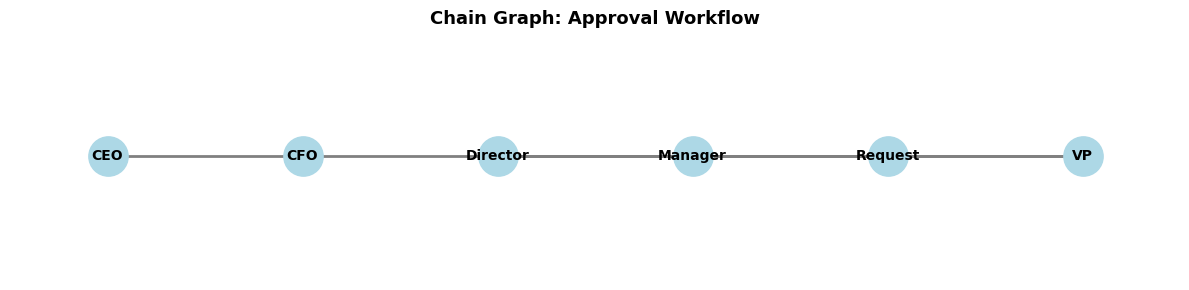

Chain graph statistics:
Nodes: 6
Edges: 5
Density: 0.333
Connected components: 1

Degree of each node:
  Request: 1
  Manager: 2
  Director: 2
  VP: 2
  CFO: 2
  CEO: 1


In [33]:
# Create a chain graph
G_chain = nx.path_graph(6)
# Relabel nodes with meaningful names
chain_labels = {0: 'Request', 1: 'Manager', 2: 'Director', 3: 'VP', 4: 'CFO', 5: 'CEO'}
G_chain = nx.relabel_nodes(G_chain, chain_labels)

# Custom layout: horizontal line
pos_chain = {node: (i, 0) for i, node in enumerate(sorted(G_chain.nodes()))}

fig, ax = plt.subplots(figsize=(12, 3))
nx.draw_networkx_nodes(G_chain, pos_chain, node_color='lightblue', node_size=800, ax=ax)
nx.draw_networkx_edges(G_chain, pos_chain, edge_color='gray', width=2, ax=ax)
nx.draw_networkx_labels(G_chain, pos_chain, font_size=10, font_weight='bold', ax=ax)
ax.set_title("Chain Graph: Approval Workflow", fontsize=13, fontweight='bold')
ax.axis('off')
ax.set_xlim(-0.5, 5.5)
plt.tight_layout()
plt.show()

print("Chain graph statistics:")
print_graph_stats(G_chain)
print(f"\nDegree of each node:")
for node, deg in dict(G_chain.degree()).items():
    print(f"  {node}: {deg}")

## 5. Shape 2: Star (Hub-and-Spoke)

**Structure**: One central node connected to all others. All paths go through the center.

**Characteristics**:
- Central node has degree = n-1 (connected to all others)
- Outer nodes all have degree 1
- Two disconnected outer nodes are NOT directly connected

**Real-world examples**:
- Manager with direct reports: Manager ← all ICs
- Support ticket router: All customers → single support hub → specialists
- API gateway: All clients → single gateway → backend services

**Key risk**: Single point of failure. If the hub (manager, router, gateway) is down, the entire network disconnects.

**Reflection questions**:
- *What happens if the hub fails?*
- *What's the betweenness centrality of the center? (Hint: How many shortest paths pass through it?)*

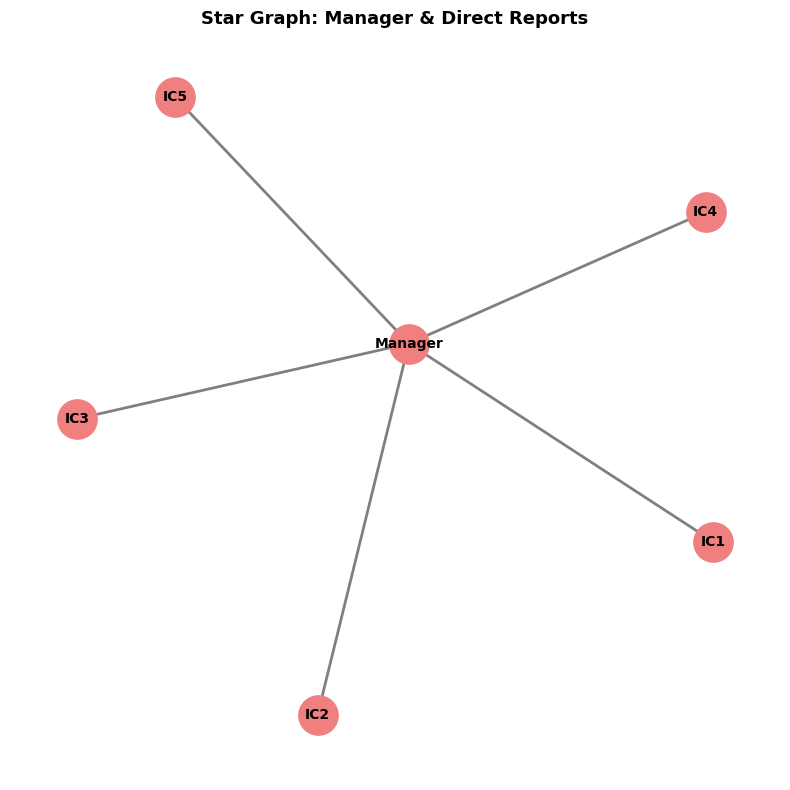

Star graph statistics:
Nodes: 6
Edges: 5
Density: 0.333
Connected components: 1

Degree of each node:
  IC1: 1
  IC2: 1
  IC3: 1
  IC4: 1
  IC5: 1
  Manager: 5

Betweenness centrality (how many paths go through each node):
  Manager: 1.000
  IC1: 0.000
  IC2: 0.000
  IC3: 0.000
  IC4: 0.000
  IC5: 0.000


In [34]:
# Create a star graph
G_star = nx.star_graph(5)  # Center + 5 outer nodes
star_labels = {0: 'Manager', 1: 'IC1', 2: 'IC2', 3: 'IC3', 4: 'IC4', 5: 'IC5'}
G_star = nx.relabel_nodes(G_star, star_labels)

# Custom radial layout
pos_star = nx.spring_layout(G_star, seed=42, k=2)

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(G_star, pos_star, node_color='lightcoral', node_size=800, ax=ax)
nx.draw_networkx_edges(G_star, pos_star, edge_color='gray', width=2, ax=ax)
nx.draw_networkx_labels(G_star, pos_star, font_size=10, font_weight='bold', ax=ax)
ax.set_title("Star Graph: Manager & Direct Reports", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Star graph statistics:")
print_graph_stats(G_star)
print(f"\nDegree of each node:")
for node in sorted(G_star.nodes()):
    print(f"  {node}: {G_star.degree(node)}")

# Compute betweenness centrality
betweenness = nx.betweenness_centrality(G_star)
print(f"\nBetweenness centrality (how many paths go through each node):")
for node, bc in sorted(betweenness.items(), key=lambda x: x[1], reverse=True):
    print(f"  {node}: {bc:.3f}")

## 6. Shape 3: Ring (Cycle)

**Structure**: Nodes arranged in a circle: 1→2→3→4→5→1. Every node is reachable from every other.

**Characteristics**:
- All nodes have degree 2
- Multiple paths exist between nodes
- Network remains connected if any single edge is removed

**Real-world examples**:
- Redundant approval paths: If direct manager unavailable, escalate to peer → their manager → back down
- Backup network topology: Nodes connected in a loop for resilience
- Circular dependency (dangerous): A → B → C → A (indicate design flaw)

**Key advantage**: Redundancy. One broken link doesn't disconnect the graph.

**Reflection**: *How does a ring differ from a chain in resilience?*

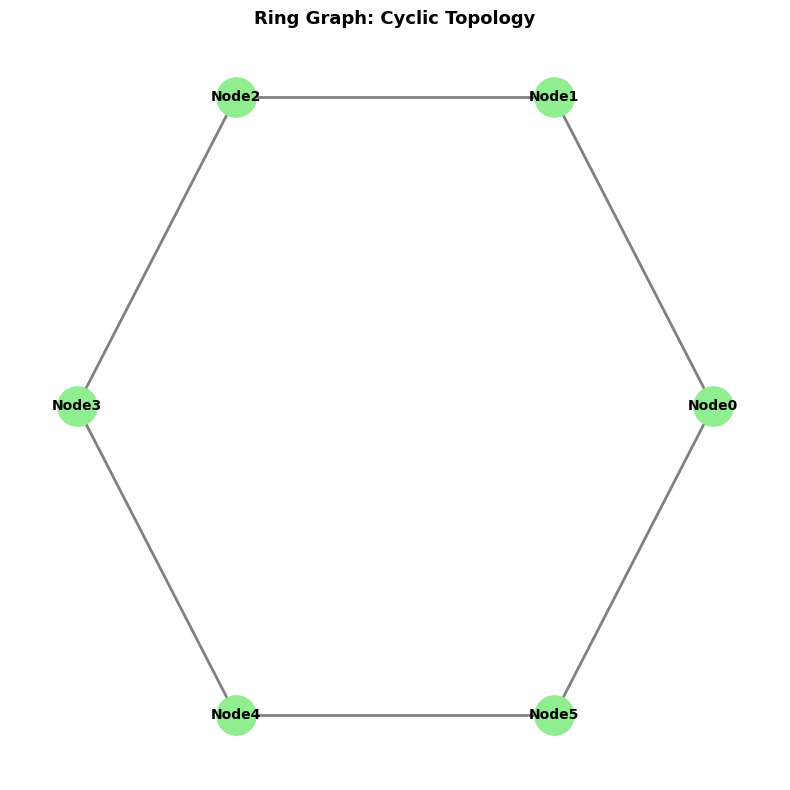

Ring graph statistics:
Nodes: 6
Edges: 6
Density: 0.400
Connected components: 1

Degree of each node:
  Node0: 2
  Node1: 2
  Node2: 2
  Node3: 2
  Node4: 2
  Node5: 2


In [35]:
# Create a ring (cycle) graph
G_ring = nx.cycle_graph(6)
ring_labels = {i: f'Node{i}' for i in range(6)}
G_ring = nx.relabel_nodes(G_ring, ring_labels)

# Circular layout
pos_ring = nx.circular_layout(G_ring)

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(G_ring, pos_ring, node_color='lightgreen', node_size=800, ax=ax)
nx.draw_networkx_edges(G_ring, pos_ring, edge_color='gray', width=2, ax=ax)
nx.draw_networkx_labels(G_ring, pos_ring, font_size=10, font_weight='bold', ax=ax)
ax.set_title("Ring Graph: Cyclic Topology", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Ring graph statistics:")
print_graph_stats(G_ring)
print(f"\nDegree of each node:")
for node in sorted(G_ring.nodes()):
    print(f"  {node}: {G_ring.degree(node)}")

## 7. Shape 4: Complete Graph

**Structure**: Every node is directly connected to every other node. No intermediaries needed.

**Characteristics**:
- All nodes have degree = n-1
- Extremely high density
- Number of edges = n(n-1)/2 (grows quadratically with nodes)

**Real-world examples**:
- Small fully-connected team: 5 people, all can call/message all (works fine)
- Board of directors: Everyone can vote on everything
- ***Rarely seen beyond 10-15 nodes*** because coordination cost explodes

**Key limitation**: Does not scale. A complete graph with 100 nodes has 4,950 edges. Communications become chaotic.

**Reflection**: *Why are complete graphs rare at scale?*

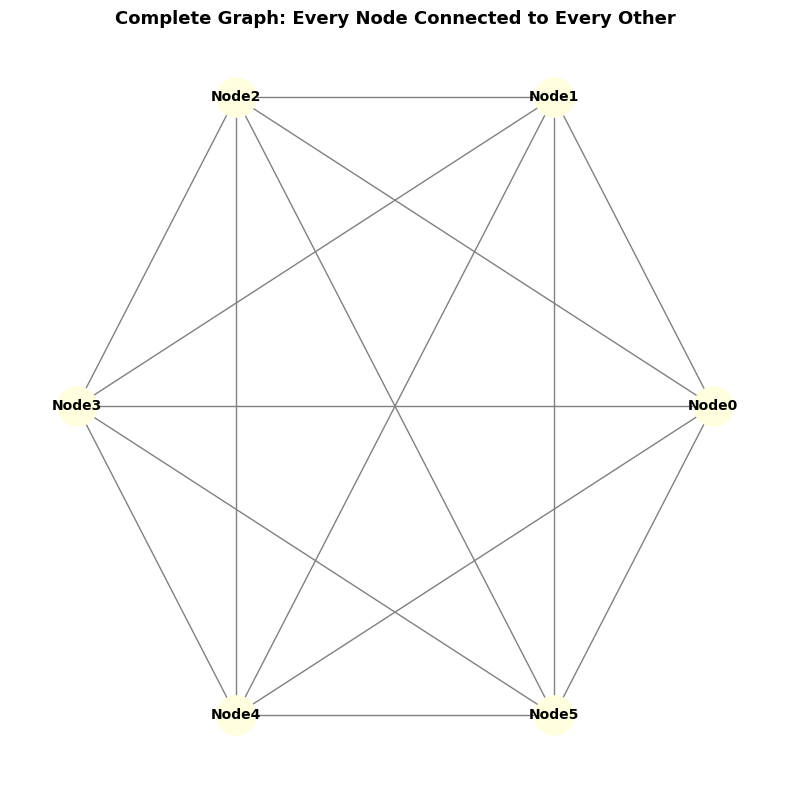

Complete graph statistics:
Nodes: 6
Edges: 15
Density: 1.000
Connected components: 1

Degree of each node:
  Node0: 5
  Node1: 5
  Node2: 5
  Node3: 5
  Node4: 5
  Node5: 5

--- Scaling Complete Graphs ---
n=  3 nodes →     3 edges
n=  5 nodes →    10 edges
n=  6 nodes →    15 edges
n= 10 nodes →    45 edges
n= 20 nodes →   190 edges
n=100 nodes →  4950 edges


In [36]:
# Create a complete graph (6 nodes, consistent with other shapes)
G_complete = nx.complete_graph(6)
complete_labels = {i: f'Node{i}' for i in range(6)}
G_complete = nx.relabel_nodes(G_complete, complete_labels)

pos_complete = nx.circular_layout(G_complete)

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(G_complete, pos_complete, node_color='lightyellow', node_size=800, ax=ax)
nx.draw_networkx_edges(G_complete, pos_complete, edge_color='gray', width=1, ax=ax)
nx.draw_networkx_labels(G_complete, pos_complete, font_size=10, font_weight='bold', ax=ax)
ax.set_title("Complete Graph: Every Node Connected to Every Other", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Complete graph statistics:")
print_graph_stats(G_complete)
print(f"\nDegree of each node:")
for node in sorted(G_complete.nodes()):
    print(f"  {node}: {G_complete.degree(node)}")

# Compare edge counts
print(f"\n--- Scaling Complete Graphs ---")
for n in [3, 5, 6, 10, 20, 100]:
    G_test = nx.complete_graph(n)
    edges = G_test.number_of_edges()
    print(f"n={n:3d} nodes → {edges:5d} edges")

## 8. Shape 5: Bipartite Graph

**Structure**: Two distinct groups of nodes. Edges exist **only between groups**, never within a group.

**Characteristics**:
- Nodes can be colored with 2 colors such that adjacent nodes have different colors
- No edges connect nodes within the same group
- Used for matching problems

**Real-world examples**:
- Employees ↔ Projects: Alice works on ProjectA, ProjectB; Bob works on ProjectB, ProjectC (no employee-employee edges, no project-project edges)
- Students ↔ Courses: Students enroll in courses
- Buyers ↔ Suppliers: Buyers purchase from suppliers
- Authors ↔ Papers: Authors write papers

**Key advantage**: Specialized algorithms exist for bipartite matching, recommendation, and analysis.

**Reflection**: *What algorithms work specifically on bipartite graphs? (Hint: Think about matching or recommendations.)*

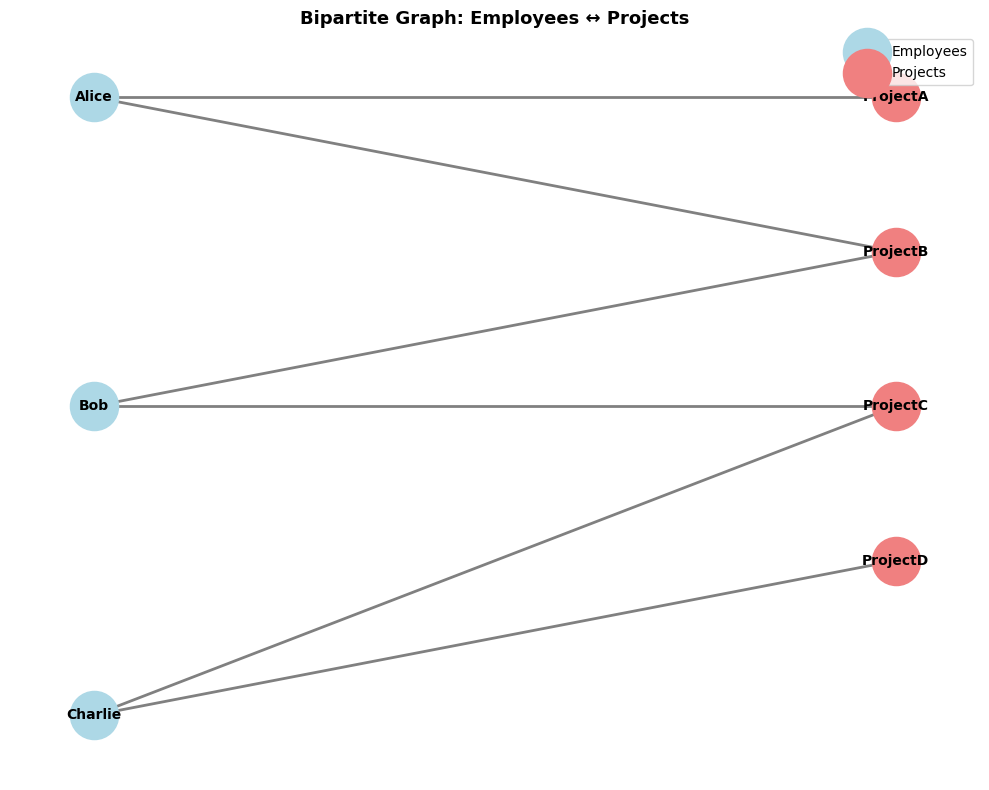

Bipartite graph statistics:
Nodes: 7
Edges: 6
Density: 0.286
Connected components: 1

Is this graph bipartite? True

Assignments (edges):
  Alice → ProjectA
  Alice → ProjectB
  Bob → ProjectB
  Bob → ProjectC
  Charlie → ProjectC
  Charlie → ProjectD


In [37]:
# Create a bipartite graph: employees and projects
from networkx.algorithms import bipartite

G_bipartite = nx.Graph()

# Add employee nodes (set 0)
employees = ['Alice', 'Bob', 'Charlie']
G_bipartite.add_nodes_from(employees, bipartite=0)

# Add project nodes (set 1)
projects = ['ProjectA', 'ProjectB', 'ProjectC', 'ProjectD']
G_bipartite.add_nodes_from(projects, bipartite=1)

# Add assignments (edges between employees and projects)
assignments = [
    ('Alice', 'ProjectA'),
    ('Alice', 'ProjectB'),
    ('Bob', 'ProjectB'),
    ('Bob', 'ProjectC'),
    ('Charlie', 'ProjectC'),
    ('Charlie', 'ProjectD'),
]
G_bipartite.add_edges_from(assignments)

# Two-column layout: employees left, projects right
pos_bipartite = {}
for i, emp in enumerate(employees):
    pos_bipartite[emp] = (0, -i)
for i, proj in enumerate(projects):
    pos_bipartite[proj] = (2, -i/2)

fig, ax = plt.subplots(figsize=(10, 8))

# Draw employees in one color
nx.draw_networkx_nodes(G_bipartite, pos_bipartite, nodelist=employees, 
                       node_color='lightblue', node_size=1200, ax=ax, label='Employees')
# Draw projects in another color
nx.draw_networkx_nodes(G_bipartite, pos_bipartite, nodelist=projects, 
                       node_color='lightcoral', node_size=1200, ax=ax, label='Projects')

nx.draw_networkx_edges(G_bipartite, pos_bipartite, edge_color='gray', width=2, ax=ax)
nx.draw_networkx_labels(G_bipartite, pos_bipartite, font_size=10, font_weight='bold', ax=ax)
ax.set_title("Bipartite Graph: Employees ↔ Projects", fontsize=13, fontweight='bold')
ax.axis('off')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Bipartite graph statistics:")
print_graph_stats(G_bipartite)
print(f"\nIs this graph bipartite? {bipartite.is_bipartite(G_bipartite)}")
print(f"\nAssignments (edges):")
for emp, proj in G_bipartite.edges():
    print(f"  {emp} → {proj}")

## 9. Same Nodes, Different Structures

Here's the key insight: **Structure determines algorithm outcomes.**

We'll create 5 different graphs, all with exactly 6 nodes, but with different topologies. Then we'll compute centrality (importance) for each node. Watch how the rankings change!

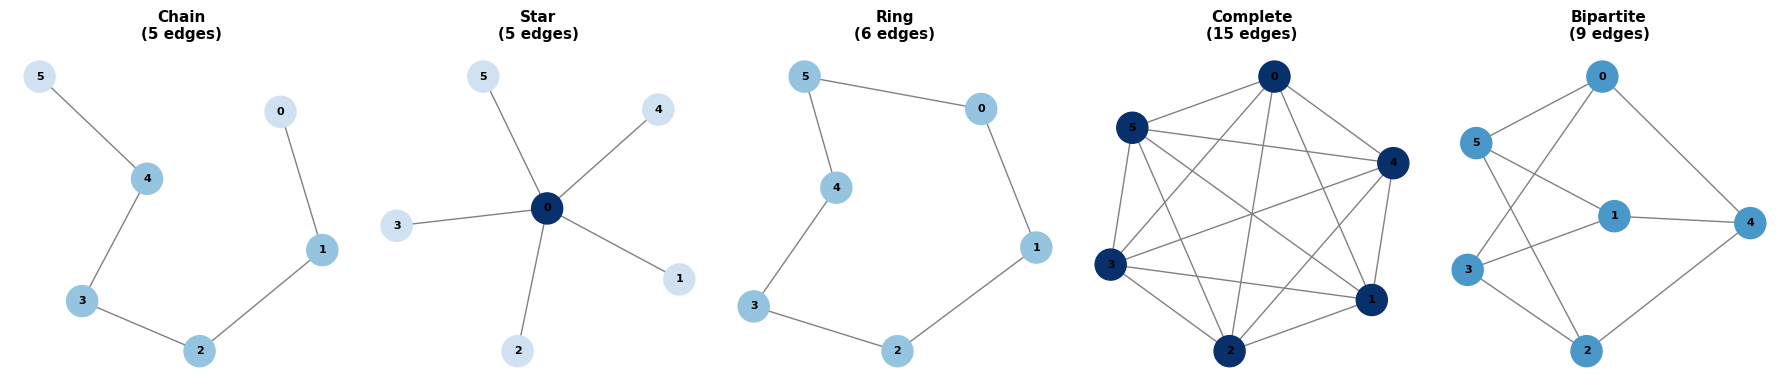


DEGREE CENTRALITY RANKINGS (Top 3 Most Important Nodes)

Chain:
  1. Node 1: 0.400
  2. Node 2: 0.400
  3. Node 3: 0.400

Star:
  1. Node 0: 1.000
  2. Node 1: 0.200
  3. Node 2: 0.200

Ring:
  1. Node 0: 0.400
  2. Node 1: 0.400
  3. Node 2: 0.400

Complete:
  1. Node 0: 1.000
  2. Node 1: 1.000
  3. Node 2: 1.000

Bipartite:
  1. Node 0: 0.600
  2. Node 1: 0.600
  3. Node 2: 0.600

KEY INSIGHT: Same 6 nodes → Different importance rankings!
Structure determines which nodes are critical.


In [38]:
# Create 5 graphs with 6 nodes each, representing the five canonical shapes taught above
structures = {}

# 1. Chain
G_chain_6 = nx.path_graph(6)
structures['Chain'] = G_chain_6

# 2. Star (center node is 0, outer nodes are 1-5)
G_star_6 = nx.star_graph(5)
structures['Star'] = G_star_6

# 3. Ring
G_ring_6 = nx.cycle_graph(6)
structures['Ring'] = G_ring_6

# 4. Complete (every node connects to every other)
G_complete_6 = nx.complete_graph(6)
structures['Complete'] = G_complete_6

# 5. Bipartite (3 nodes in group A, 3 in group B; edges only between groups)
# Group A: nodes 0, 1, 2 (employees)
# Group B: nodes 3, 4, 5 (projects)
# Edges create full connections between groups
G_bipartite_6 = nx.Graph()
G_bipartite_6.add_nodes_from([0, 1, 2], bipartite=0)  # Group A
G_bipartite_6.add_nodes_from([3, 4, 5], bipartite=1)  # Group B
G_bipartite_6.add_edges_from([
    (0, 3), (0, 4), (0, 5),
    (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
])
structures['Bipartite'] = G_bipartite_6

# Compute degree centrality for each
centralities = {}
for name, G in structures.items():
    centralities[name] = nx.degree_centrality(G)

# Visualize all 5 side-by-side
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, (name, G) in enumerate(structures.items()):
    ax = axes[idx]
    pos = nx.spring_layout(G, seed=42, k=1.5)
    
    # Color nodes by degree centrality (important nodes = darker)
    centrality_values = list(centralities[name].values())
    nx.draw_networkx_nodes(G, pos, node_color=centrality_values, node_size=500, 
                          cmap='Blues', ax=ax, vmin=0, vmax=1)
    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    ax.set_title(f"{name}\n({G.number_of_edges()} edges)", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DEGREE CENTRALITY RANKINGS (Top 3 Most Important Nodes)")
print("="*70)

for name in structures.keys():
    sorted_centrality = sorted(centralities[name].items(), key=lambda x: x[1], reverse=True)
    print(f"\n{name}:")
    for i, (node, centrality) in enumerate(sorted_centrality[:3], 1):
        print(f"  {i}. Node {node}: {centrality:.3f}")

print("\n" + "="*70)
print("KEY INSIGHT: Same 6 nodes → Different importance rankings!")
print("Structure determines which nodes are critical.")
print("="*70)

In [39]:
# Sanity Check: Verify that the five structures match the taught shapes
print("=" * 70)
print("SANITY CHECK: Verifying the five canonical shapes")
print("=" * 70)

# Check 1: All five expected shapes are present
expected_shapes = {"Chain", "Star", "Ring", "Complete", "Bipartite"}
actual_shapes = set(structures.keys())
assert actual_shapes == expected_shapes, f"Shape mismatch! Expected {expected_shapes}, got {actual_shapes}"
print("✓ All five canonical shapes are present")

# Check 2: Each graph has 6 nodes
for name, G in structures.items():
    assert G.number_of_nodes() == 6, f"Shape '{name}' has {G.number_of_nodes()} nodes, expected 6"
print("✓ Each graph has exactly 6 nodes")

# Check 3: Centrality dictionary has one entry per node (for each graph)
for name, cent_dict in centralities.items():
    assert len(cent_dict) == 6, f"Centrality dict for '{name}' has {len(cent_dict)} entries, expected 6"
print("✓ Each centrality dictionary has 6 entries (one per node)")

# Check 4: Display basic properties to confirm correct shapes
print("\nGraph Properties:")
for name, G in structures.items():
    density = nx.density(G)
    print(f"  {name:10s}: {G.number_of_nodes()} nodes, {G.number_of_edges():2d} edges, density={density:.3f}")

SANITY CHECK: Verifying the five canonical shapes
✓ All five canonical shapes are present
✓ Each graph has exactly 6 nodes
✓ Each centrality dictionary has 6 entries (one per node)

Graph Properties:
  Chain     : 6 nodes,  5 edges, density=0.333
  Star      : 6 nodes,  5 edges, density=0.333
  Ring      : 6 nodes,  6 edges, density=0.400
  Complete  : 6 nodes, 15 edges, density=1.000
  Bipartite : 6 nodes,  9 edges, density=0.600


## 10. When to Use Graphs

**Use graphs when:**

1. **Relationships matter**. The structure of connections affects outcomes. Example: Risk propagates through your supply chain, so removing one supplier changes your exposure.

2. **Structure drives algorithm choice**. You want to find shortest paths, bottlenecks, clusters, or influence spreads. Tables (CSV) don't capture this naturally.

3. **Multiple paths exist** or you care about path diversity. Example: Approval can go through Manager or Peer → Manager, so you need to model both routes.

4. **Connection patterns reveal insights**. Centrality, clusters, bridges. Example: The person with highest betweenness centrality is your key information broker.

**Do NOT use graphs when:**

- Relationships are one-directional only (e.g., only summarized reports, no interactions). Use a table.
- Structure doesn't affect the analysis. Example: If you only care about the count of employees (not who reports to whom), a number suffices.
- Your data is simple hierarchy with no cycles or alternative paths. A tree (special case of graph) or org chart is simpler.

**Next lessons**: We'll learn algorithms that exploit graph structure (centrality, communities, paths, flows) to solve business problems.

## 11. Student Exercises

### Exercise 1: Represent an Approval Chain

You have a 6-person team: 2 managers and 4 individual contributors (ICs).

- Managers: Alice (VP), Bob (Manager)
- ICs: C1, C2, C3, C4

The approval rule is: **Any IC can report to any manager, and any manager can report to the VP.**

**Question**: What graph shape is this? Is it a chain, a star, or something else? Explain why.

**Then create the graph in code and visualize it.**

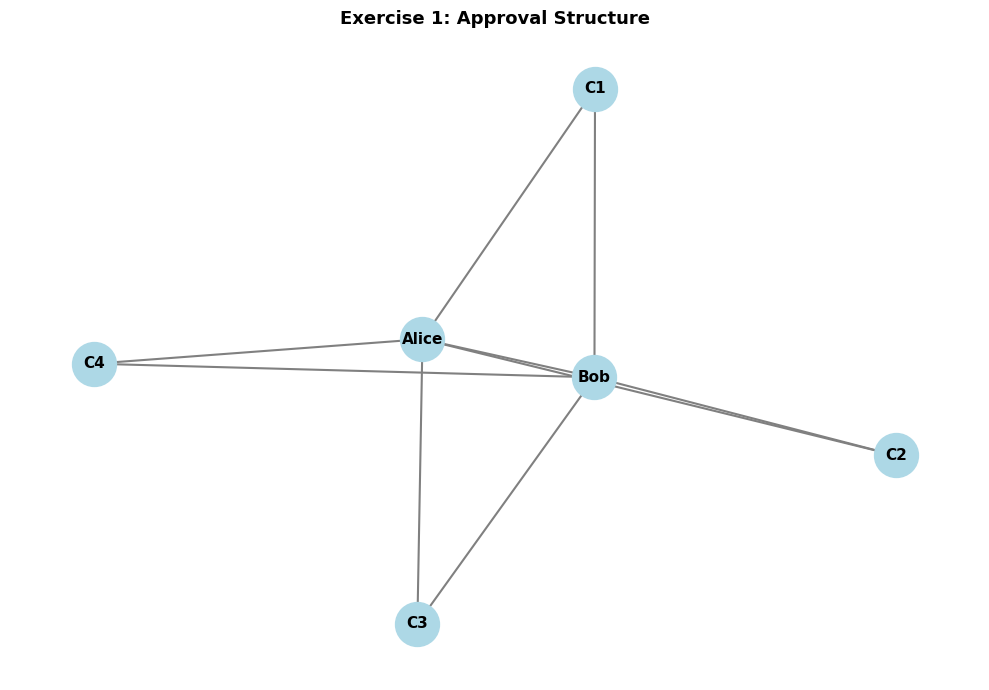

Graph Statistics:
Nodes: 6
Edges: 9
Density: 0.600
Connected components: 1

Degree of each node:
  Alice: 5
  Bob: 5
  C1: 2
  C2: 2
  C3: 2
  C4: 2

** ANSWER **
This is a BIPARTITE graph! ICs on one side, managers on the other.
It's also nearly complete between the two groups (all ICs connect to all managers).
It has 9 edges, and is heavily connected.


In [44]:
# SOLUTION: Exercise 1

G_exercise1 = nx.Graph()

# Add nodes
G_exercise1.add_nodes_from(['C1', 'C2', 'C3', 'C4', 'Bob', 'Alice'])

# Each IC can report to each manager
for ic in ['C1', 'C2', 'C3', 'C4']:
    for mgr in ['Bob', 'Alice']:
        G_exercise1.add_edge(ic, mgr)

# Manager reports to VP
G_exercise1.add_edge('Bob', 'Alice')

pos_ex1 = nx.spring_layout(G_exercise1, seed=42, k=2)

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G_exercise1, pos_ex1, node_color='lightblue', node_size=1000, ax=ax)
nx.draw_networkx_edges(G_exercise1, pos_ex1, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G_exercise1, pos_ex1, font_size=11, font_weight='bold', ax=ax)
ax.set_title("Exercise 1: Approval Structure", fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("Graph Statistics:")
print_graph_stats(G_exercise1)
print(f"\nDegree of each node:")
for node in sorted(G_exercise1.nodes()):
    print(f"  {node}: {G_exercise1.degree(node)}")

print("\n** ANSWER **")
print("This is a BIPARTITE graph! ICs on one side, managers on the other.")
print("It's also nearly complete between the two groups (all ICs connect to all managers).")
print(f"It has {G_exercise1.number_of_edges()} edges, and is heavily connected.")

### Exercise 2: Project Team Assignments

You have a 5-person team and 8 different tasks. Each person is assigned to 3 tasks, and each task should have 2 people (note: with 15 total assignments for 8 tasks, one task will have only 1 person).

**Assignments:**
- Person A: Tasks 1, 2, 3
- Person B: Tasks 2, 4, 5
- Person C: Tasks 3, 5, 6
- Person D: Tasks 1, 6, 7
- Person E: Tasks 4, 7, 8

**Question**: Create a bipartite graph of people and tasks. What does the graph tell you about task distribution? Are any tasks overloaded or understaffed?

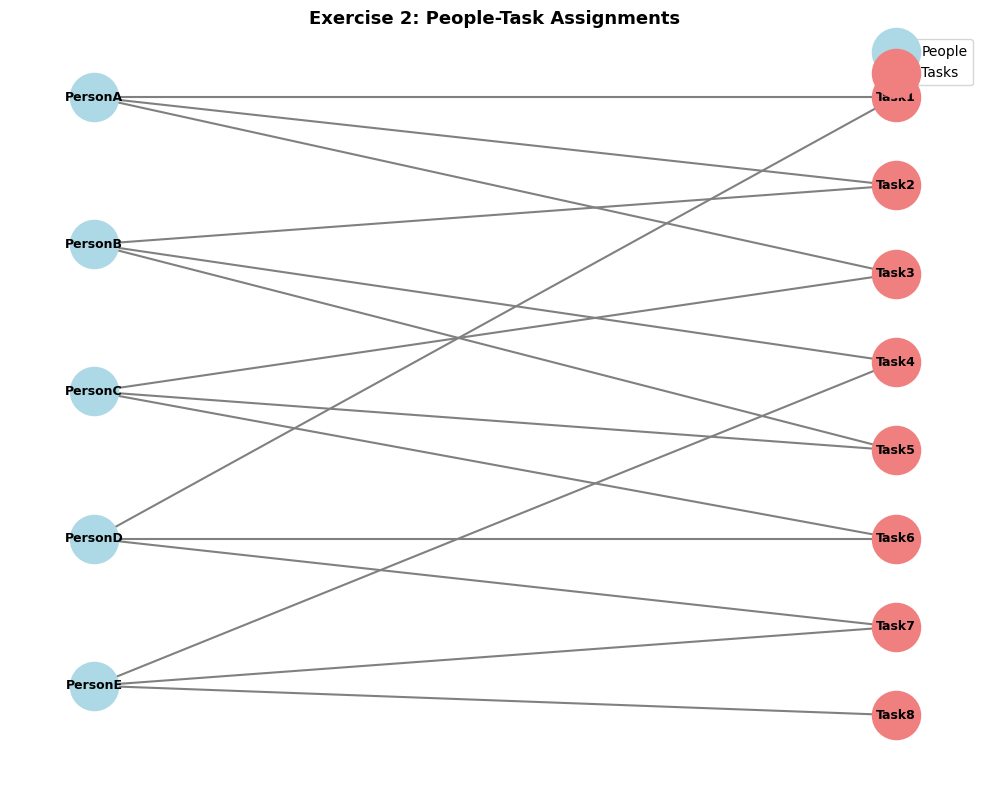

Task Coverage Analysis:
  Task1: 2 people ['PersonA', 'PersonD'] ✓ OK
  Task2: 2 people ['PersonA', 'PersonB'] ✓ OK
  Task3: 2 people ['PersonA', 'PersonC'] ✓ OK
  Task4: 2 people ['PersonB', 'PersonE'] ✓ OK
  Task5: 2 people ['PersonB', 'PersonC'] ✓ OK
  Task6: 2 people ['PersonC', 'PersonD'] ✓ OK
  Task7: 2 people ['PersonD', 'PersonE'] ✓ OK
  Task8: 1 people ['PersonE'] ✗ PROBLEM

** ANSWER **
All tasks have exactly 2 people assigned.
All people have exactly 3 tasks.
The distribution is perfectly balanced—no bottlenecks or understaffing.


In [45]:
# SOLUTION: Exercise 2

G_exercise2 = nx.Graph()

# Add people (set 0) and tasks (set 1)
people = ['PersonA', 'PersonB', 'PersonC', 'PersonD', 'PersonE']
tasks = ['Task1', 'Task2', 'Task3', 'Task4', 'Task5', 'Task6', 'Task7', 'Task8']

G_exercise2.add_nodes_from(people, bipartite=0)
G_exercise2.add_nodes_from(tasks, bipartite=1)

# Add assignments
assignments_ex2 = [
    ('PersonA', 'Task1'), ('PersonA', 'Task2'), ('PersonA', 'Task3'),
    ('PersonB', 'Task2'), ('PersonB', 'Task4'), ('PersonB', 'Task5'),
    ('PersonC', 'Task3'), ('PersonC', 'Task5'), ('PersonC', 'Task6'),
    ('PersonD', 'Task1'), ('PersonD', 'Task6'), ('PersonD', 'Task7'),
    ('PersonE', 'Task4'), ('PersonE', 'Task7'), ('PersonE', 'Task8'),
]
G_exercise2.add_edges_from(assignments_ex2)

# Bipartite layout
pos_ex2 = {}
for i, p in enumerate(people):
    pos_ex2[p] = (0, -i)
for i, t in enumerate(tasks):
    pos_ex2[t] = (3, -i*0.6)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G_exercise2, pos_ex2, nodelist=people, 
                       node_color='lightblue', node_size=1200, ax=ax, label='People')
nx.draw_networkx_nodes(G_exercise2, pos_ex2, nodelist=tasks, 
                       node_color='lightcoral', node_size=1200, ax=ax, label='Tasks')
nx.draw_networkx_edges(G_exercise2, pos_ex2, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G_exercise2, pos_ex2, font_size=9, font_weight='bold', ax=ax)
ax.set_title("Exercise 2: People-Task Assignments", fontsize=13, fontweight='bold')
ax.axis('off')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Task Coverage Analysis:")
for task in sorted(tasks):
    staff_count = G_exercise2.degree(task)
    staff = list(G_exercise2.neighbors(task))
    status = "✓ OK" if staff_count == 2 else "✗ PROBLEM" if staff_count < 2 else "⚠ Overloaded"
    print(f"  {task}: {staff_count} people {staff} {status}")

print("\n** ANSWER **")
print("All tasks have exactly 2 people assigned.")
print("All people have exactly 3 tasks.")
print("The distribution is perfectly balanced—no bottlenecks or understaffing.")

### Exercise 3: Real Organization Graphs

Think about your organization (or a company you know). Sketch 3 important graphs:

1. **Reporting Structure** (hierarchy)
2. **Approval Chain** (how decisions flow)
3. **Communication Network** (who talks to whom most often)

For each graph:
- **Identify the shape**: Is it a chain, star, ring, complete, bipartite, or hybrid?
- **Explain why**: What drives the structure? (e.g., "approval is a chain because compliance requires sequential sign-offs")
- **Identify risks**: What node is most critical? What single failure would hurt most?

**No code required for this exercise—just reflection and discussion.**

## 12. Key Takeaways

### The Five Graph Shapes

| Shape | Structure | Risk | Example |
|-------|-----------|------|----------|
| **Chain** | Sequential: 1→2→3→4 | Single bottleneck | Approval chain, supply chain |
| **Star** | Hub + spokes | Hub failure breaks everything | Manager + reports, API gateway |
| **Ring** | Cycle: 1→2→3→1 | Redundant, resilient | Backup loops, redundant networks |
| **Complete** | Everyone connects to everyone | Coordination chaos at scale | Small fully-connected teams |
| **Bipartite** | Two groups, edges only between | Specialized matching algorithms | Employees ↔ Projects, Students ↔ Courses |

### Key Principles

1. **Structure determines outcomes.** Same 6 nodes, different topology → different centrality rankings.

2. **Directed matters.** Approval goes one way (Request → Manager → VP), not both.

3. **Weights matter.** The cost of a path is not just "how many steps" but the sum of weights (time, money, risk).

4. **Graphs reveal bottlenecks and redundancy.** Nodes with high betweenness centrality are critical. Rings are resilient. Stars are fragile.

5. **Algorithms are shape-specific.** Community detection works on any graph. Bipartite matching only works on bipartite graphs.

### Next Steps

**Lesson 02 - NetworkX Foundations**: Learn to build graphs from real data (CSV files), add complex attributes, filter, export, and reload.

**Lesson 03 - Graph Profiling**: Measure graphs systematically. Degree distribution, clustering, components. Find anomalies.

**Lesson 04 - Centrality Algorithms**: Go deep. Degree, betweenness, closeness, PageRank, eigenvector. Understand what "important" means.

---

**Congratulations!** You now understand graph thinking. Structure matters. Next, you'll build real graphs from data and run algorithms on them.